# Running Polarimetric fits with an MCMC

LeakageLib provides a simple way to run polarimetric fits with an MCMC, instead of the standard method. You would use the `fit_mcmc` function instead of `fit`. MCMC fitting requires the emcee and corner packages. To make sure you have them installed, we import them now.

In [1]:
import emcee, corner

This example recreates the point-source-fit example, with mcmc fitting. First, we repeat the setup described in that example.

In [2]:
import leakagelib

datas = leakagelib.IXPEData.load_all_detectors_with_path("data", "ps")
for data in datas:
    data.iterative_centroid_center()
    data.retain(data.evt_energies > 2)
    data.retain(data.evt_energies < 8)

settings = leakagelib.FitSettings(datas)
settings.apply_circular_roi(280)

settings.add_point_source() # Named "src" by default
settings.fix_flux("src", 1)
settings.set_initial_qu("src", (0.5,0))
settings.set_spectrum("src", lambda e: e**-1.5) # Gamma=1.5, unabsorbed powerlaw

settings.add_background() # Named "bkg" by default
settings.fix_qu("bkg", (0, 0)) # Assume an unpolarized background
settings.add_particle_background() # Named "pbkg" by default
settings.fix_qu("pbkg", (0, 0)) # Assume the particles have no direction dependence
settings.set_spectrum("bkg", lambda e: e**-2.5) # Gamma=2.5, unabsorbed powerlaw

fitter = leakagelib.Fitter(settings)

>>> PyXSPEC is not installed, you will no be able to use it.
>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...
6478 events were cut for being outside the region of interest.
>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...
>>> Using cached xVignetting object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...
>>> Using cached xEffectiveArea object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...
>>> Using cached xVignetting object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...
Data set ps DU 1 had no exposure map loaded. Please load an exposure map if y

Now we perform an MCMC fit simply by using the `fit_mcmc` function instead of `fit`. Note that you can save the mcmc samples to a file if you wish.

In [3]:
result = fitter.fit_mcmc(n_iter=1000)

100%|██████████| 1000/1000 [01:22<00:00, 12.16it/s]


Plotting the results shows that they suffer from a burnin problem:

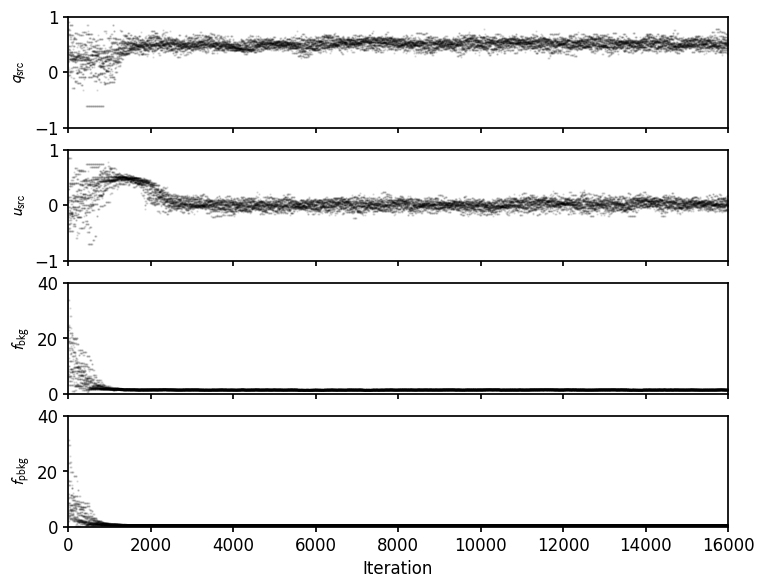

In [4]:
result.display_samples();

We can address this by removing the first few events

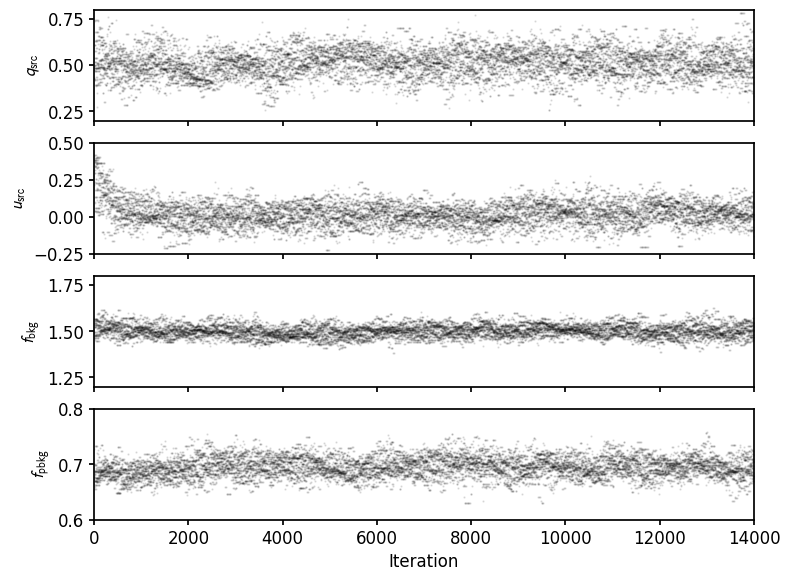

In [5]:
result.burnin(2000)
result.display_samples();

The corner plot shows nice uncertainties as well

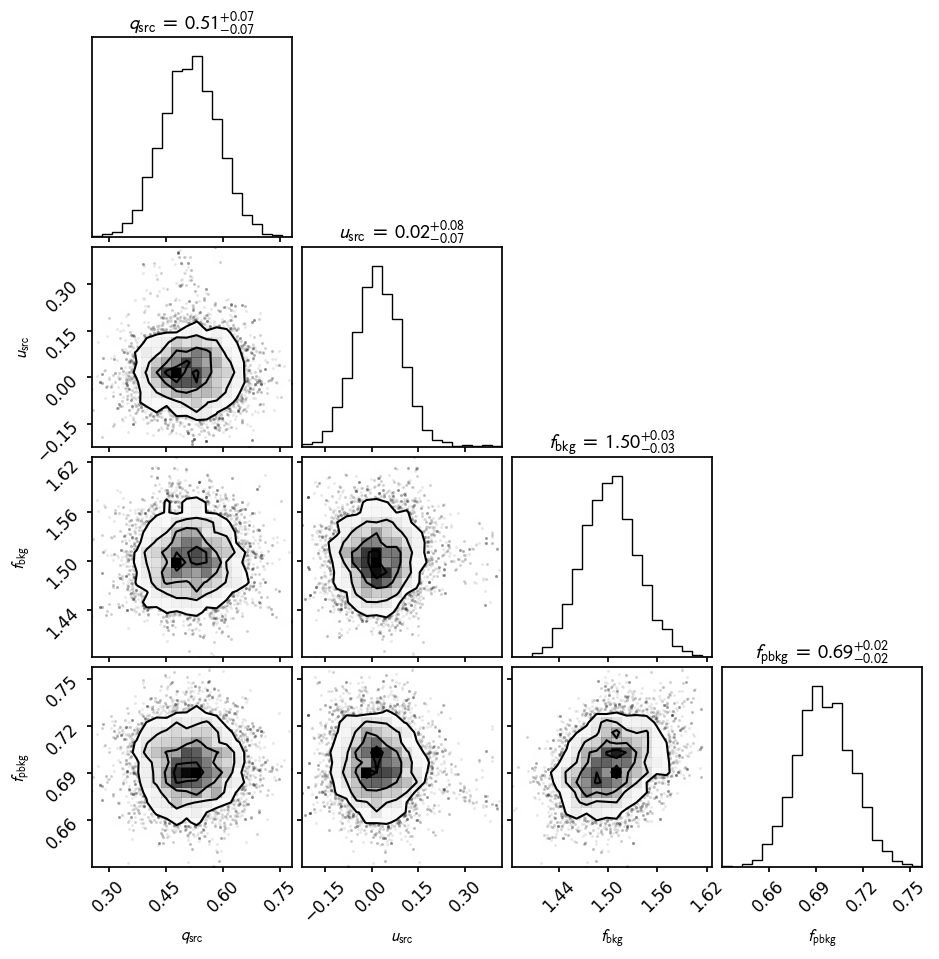

In [6]:
result.display_corner();

This fit result still acts like a normal fit result, and you can still print it to get Gaussian uncertainties. These uncertainties are the standard deviations of the sample points, whereas the faster `fit`-method uncertainties are Gaussian values obtained using Laplace's approximation, so they may not agree.

In [7]:
result

FitResult:
	q (src) = 0.5787 +/- 0.0737
	u (src) = 0.4159 +/- 0.0792
	f (bkg) = 1.4732 +/- 0.0336
	f (pbkg) = 0.6562 +/- 0.0179

Polarization:
	PD (src): 0.7127 +/- 0.0756
	PA (src): 17.8512 deg +/- 3.1095
Likelihood 10842.955029317452, dof 15688
MCMC fit

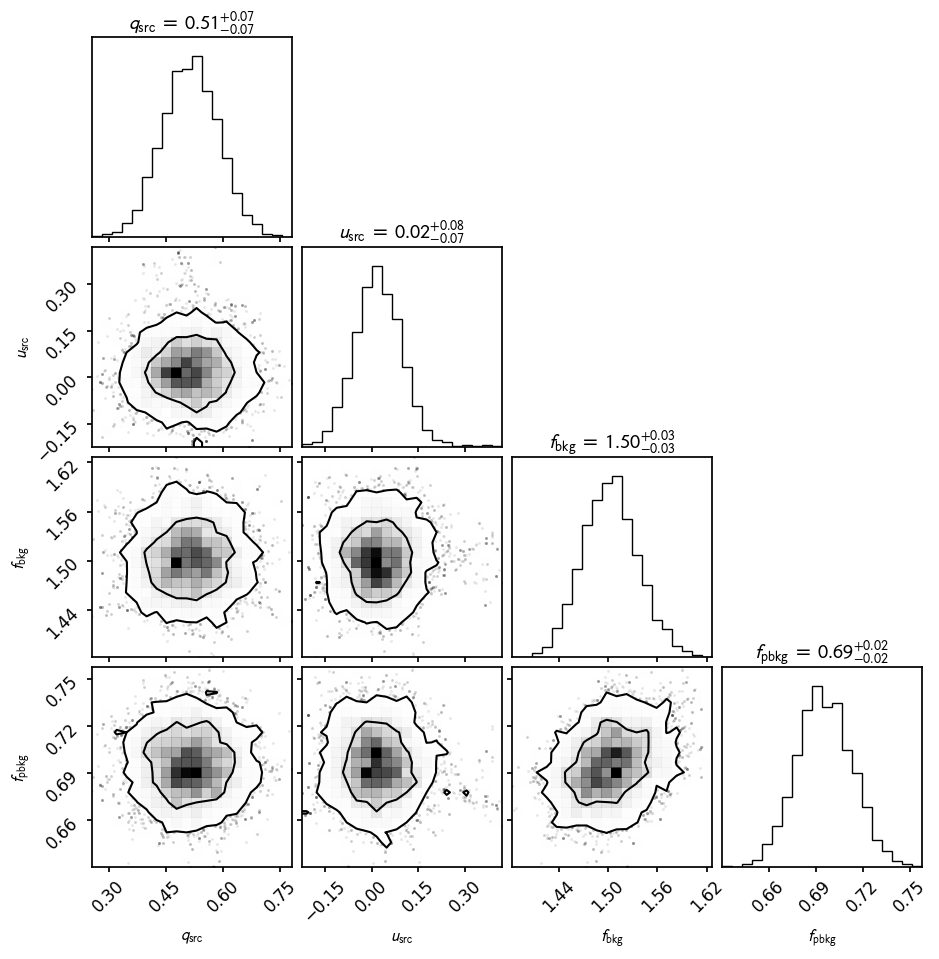

In [13]:

import corner
labels = []
for param, name in result.parameter_names:
    labels.append(f"${param}_\\mathrm{{{name}}}$")
fig = corner.corner(result.samples[result.sample_mask], labels=labels, show_titles=True, levels=(0.68, 0.95))